## Nida Noor - PKCERT AI & Software Development Internee##
## TASK 9##
**Support Vector Machines (SVM) & k-Nearest Neighbors (kNN)**

### Part A – Dataset Selection & Preparation )

**1. Select a public classification dataset.**

**2. Describe the dataset, features and target.**

**3. Preprocess the dataset (missing values, encoding, scaling).**

**4. Split the dataset into training and testing sets.**


### 1. Select a public classification dataset

The selected dataset is the Diabetes Dataset (Pima Indians Diabetes Dataset). It is a public classification dataset commonly used for predicting whether a patient has diabetes based on several medical measurements.

**Dataset Name:** Diabetes Dataset

**Problem Type:** Binary Classification

**Target Variable:** Outcome

**0** = Non-Diabetic

**1** = Diabetic

In [3]:
#1. Select a public classification dataset.
import pandas as pd

# Load the dataset
df = pd.read_csv("diabetes.csv")

# Display first five records
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### 2. Describe the dataset, features and target.

The dataset consists of medical records collected from female patients of Pima Indian heritage aged 21 years and above. Each record contains several health-related measurements that can be used to determine whether a patient is diabetic.

### Features

- **Pregnancies:** Number of times the patient has been pregnant.
- **Glucose:** Plasma glucose concentration.
- **BloodPressure:** Diastolic blood pressure (mm Hg).
- **SkinThickness:** Triceps skin fold thickness (mm).
- **Insulin:** 2-hour serum insulin (mu U/ml).
- **BMI:** Body Mass Index, calculated as weight (kg) divided by height squared (m²).
- **DiabetesPedigreeFunction:** Indicates the likelihood of diabetes based on family history.
- **Age:** Age of the patient in years.
- **Outcome:** Target variable indicating whether the patient has diabetes (0 = No, 1 = Yes).



In [5]:
#2. Describe the dataset, features and target.

# Display dataset shape
print("Dataset Shape:")
print(df.shape)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Display feature names
print("\nFeature Names:")
print(df.columns)

# Display target variable
print("\nTarget Variable Distribution:")
print(df["Outcome"].value_counts())

Dataset Shape:
(768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Statistical Summary:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  

### 3. Preprocess the dataset (missing values, encoding, scaling).

Before training the machine learning model, the dataset was preprocessed to improve data quality and model performance.

### Handling Missing Values

Some medical features contain **0** values, which are not medically valid and represent missing data. These columns include:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

The zero values were replaced with **NaN (Not a Number)** and then filled using the **median** value of each respective column. The median was chosen because it is less affected by outliers.

### Encoding

The dataset contains only numerical variables. Therefore, **no categorical encoding** was required.

### Feature Scaling

The input features were standardized using **StandardScaler**. Standardization transforms each feature so that it has:

- Mean = 0
- Standard Deviation = 1

This ensures that all features contribute equally during model training and improves the performance of many machine learning algorithms.


In [ ]:
#3. Preprocess the dataset (missing values, encoding, scaling).


import numpy as np
from sklearn.preprocessing import StandardScaler

# Columns where zero means missing value
columns_with_zero = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Check zeros in selected columns
print("Number of Zero Values Before Cleaning:\n")

for column in columns_with_zero:
    print(column, ":", (df[column] == 0).sum())

# Replace zeros with NaN
df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)

# Check missing values
print("\nMissing Values Before Filling:")
print(df.isnull().sum())

# Fill missing values using median
for column in columns_with_zero:
    df[column] = df[column].fillna(df[column].median())

# Verify missing values
print("\nMissing Values After Filling:")
print(df.isnull().sum())

# Separate features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFeature Scaling Completed Successfully.")

Number of Zero Values Before Cleaning:

Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11

Missing Values Before Filling:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing Values After Filling:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Feature Scaling Completed Successfully.


### 4. Split the dataset into training and testing sets.

After preprocessing, the dataset was divided into training and testing sets using Scikit-learn's `train_test_split()` function.

- **Training Set:** 80% of the data
- **Testing Set:** 20% of the data
- **Random State:** 42

The training set is used to train the classification model, while the testing set is used to evaluate its performance on unseen data.


In [7]:
#4. Split the dataset into training and testing sets.

from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

# Display shapes
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("Training Labels Shape   :", y_train.shape)
print("Testing Labels Shape    :", y_test.shape)

print("\nNumber of Training Samples :", len(X_train))
print("Number of Testing Samples  :", len(X_test))

Training Features Shape : (614, 8)
Testing Features Shape  : (154, 8)
Training Labels Shape   : (614,)
Testing Labels Shape    : (154,)

Number of Training Samples : 614
Number of Testing Samples  : 154


## Part B – Support Vector Machine 

Support Vector Machine (SVM) is a supervised machine learning algorithm used for both classification and regression problems. It works by finding the optimal hyperplane that separates different classes while maximizing the margin between them. In this assignment, SVM is used to classify whether a patient has diabetes based on medical features.

**1. Build an SVM model.**

**2. Choose an appropriate kernel.**

**3. Evaluate using Accuracy, Precision, Recall, F1-Score and Confusion Matrix.**

**4. Explain SVM, its advantages, limitations and applications.**


### 1. Build an SVM model.
The Support Vector Machine classifier is trained using the preprocessed training dataset. The model learns patterns from the training data and predicts whether a patient is diabetic or non-diabetic.


In [8]:
## 1. Build an SVM Model
from sklearn.svm import SVC

# Create the SVM model
svm_model = SVC(kernel='rbf', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


### 2. Choose an appropriate kernel.

The **Radial Basis Function (RBF)** kernel is selected because it performs well on datasets where the relationship between features and classes is non-linear. It maps the input data into a higher-dimensional space, allowing the SVM model to create a more effective decision boundary.

### 3. Evaluate using Accuracy, Precision, Recall, F1-Score and Confusion Matrix.

The performance of the SVM model is evaluated using the following classification metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

These metrics provide a comprehensive evaluation of the classifier's performance.

 SVM MODEL EVALUATION
Accuracy :  0.7468
Precision:  0.6667
Recall   :  0.5818
F1-Score :  0.6214

Confusion Matrix:
[[83 16]
 [23 32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.84      0.81        99
           1       0.67      0.58      0.62        55

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



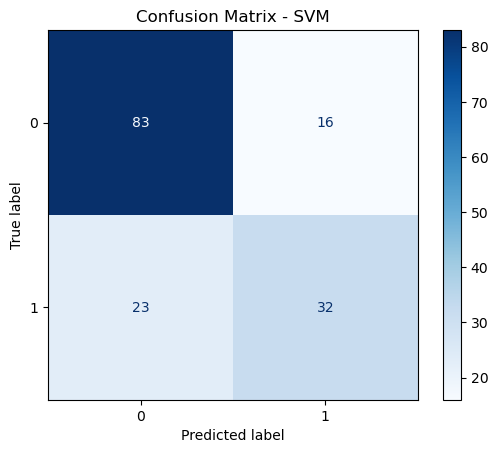

In [20]:
#3. Evaluate using Accuracy, Precision, Recall, F1-Score and Confusion Matrix.


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Make predictions
y_pred = svm_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics
print(" SVM MODEL EVALUATION")

print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1-Score :  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - SVM")
plt.show()

## 4. Explain SVM, its advantages, limitations and applications.

### What is SVM?

Support Vector Machine (SVM) is a supervised machine learning algorithm that classifies data by finding the optimal hyperplane that separates different classes with the maximum possible margin. The data points closest to the hyperplane are called **support vectors**, and they play a crucial role in defining the decision boundary.

### Advantages of SVM

- Works well for both linear and non-linear classification.
- Effective in high-dimensional datasets.
- Produces good generalization performance.
- Less prone to overfitting when the margin is maximized.
- Can use different kernel functions to solve complex classification problems.

### Limitations of SVM

- Computationally expensive for large datasets.
- Choosing the correct kernel and parameters can be challenging.
- Training time increases with dataset size.
- Less interpretable than simpler models such as Decision Trees.

### Applications of SVM

- Medical diagnosis (disease prediction)
- Image classification
- Face recognition
- Text classification and spam detection
- Handwriting recognition
- Bioinformatics
- Financial fraud detection

# Part C – k-Nearest Neighbors (kNN)

The k-Nearest Neighbors (kNN) algorithm is a supervised machine learning algorithm used for classification and regression tasks. It classifies a new data point by identifying the **K nearest neighbors** in the training dataset and assigning the class that appears most frequently among those neighbors. In this assignment, kNN is used to predict whether a patient has diabetes based on medical features.

**1. Build a kNN Model**

**2. Choose an appropriate K value.**

**3. Evaluate using Accuracy, Precision, Recall, F1-Score and Confusion Matrix.**

**4. Explain kNN, its advantages, limitations and applications.**



### 1. Build a kNN Model

A k-Nearest Neighbors (kNN) classifier is created and trained using the preprocessed training dataset. The model stores the training data and classifies new observations based on the majority class of their nearest neighbors.

In [12]:
#1. # Create the kNN model
from sklearn.neighbors import KNeighborsClassifier

# Create the kNN model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

print("kNN model trained successfully!")

kNN model trained successfully!



## 2. Choose an Appropriate K Value
The value of **K = 5** is

## 3. Evaluate using Accuracy, Precision, Recall, F1-Score and Confusion Matrix.

The performance of the kNN classifier is evaluated using several classification metrics, including Accuracy, Precision, Recall, F1-Score, and the Confusion Matrix. These metrics help measure how effectively the model classifies diabetic and non-diabetic patients.

 kNN MODEL EVALUATION
Accuracy :  0.7338
Precision:  0.6129
Recall   :  0.6909
F1-Score :  0.6496

Confusion Matrix:
[[75 24]
 [17 38]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.61      0.69      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



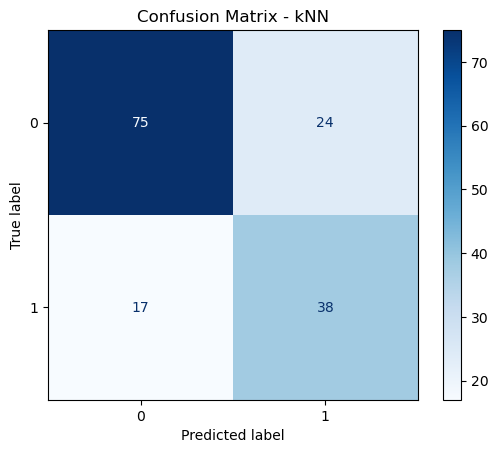

In [19]:
#3. Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Make predictions
y_pred = knn_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print evaluation metrics

print(" kNN MODEL EVALUATION")

print(f"Accuracy :  {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1-Score :  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - kNN")
plt.show()

## 4. Explain kNN, its advantages, limitations and applications.


### What is kNN?

k-Nearest Neighbors (kNN) is a supervised machine learning algorithm used for classification and regression. It predicts the class of a new data point by measuring its distance from all training samples and selecting the **K nearest neighbors**. The new data point is assigned the class that receives the majority vote among these neighbors.

### Advantages of kNN

- Simple and easy to understand.
- No training phase is required, making it a lazy learning algorithm.
- Works well for small and medium-sized datasets.
- Can model complex decision boundaries.
- Effective for both binary and multi-class classification problems.

### Limitations of kNN

- Prediction becomes slower for large datasets.
- Performance depends on the choice of K.
- Sensitive to irrelevant features and noisy data.
- Requires feature scaling because it relies on distance calculations.
- Consumes more memory since all training data must be stored.

### Applications of kNN

- Medical diagnosis and disease prediction
- Recommendation systems
- Image classification
- Pattern recognition
- Text classification
- Credit risk analysis
- Customer segmentation

# Part D – Comparative Analysis

The comparison of the two classification models shows that both **Support Vector Machine (SVM)** and **k-Nearest Neighbors (kNN)** performed well on the diabetes dataset.

- **SVM** achieved the highest **Accuracy (74.68%)** and **Precision (66.67%)**, indicating that it made more correct predictions overall and produced fewer false positive predictions.
  
- **kNN** achieved higher **Recall (69.09%)** and **F1-Score (64.96%)**, meaning it identified more diabetic patients correctly and provided a better balance between Precision and Recall.

Although kNN performs better in terms of Recall and F1-Score, **SVM is recommended for this dataset because it achieved the highest overall Accuracy and Precision**, making it the more reliable classifier overall. However, if the primary objective is to minimize missed diabetes cases, **kNN may be preferred due to its higher Recall**.

In [21]:
#1. Compare SVM and kNN Based on Performance

import pandas as pd

# Comparison of SVM and kNN performance
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "SVM": [0.7468, 0.6667, 0.5818, 0.6214],
    "kNN": [0.7338, 0.6129, 0.6909, 0.6496]
})

comparison

,Metric,SVM,kNN
0,Accuracy,0.7468,0.7338
1,Precision,0.6667,0.6129
2,Recall,0.5818,0.6909
3,F1-Score,0.6214,0.6496
